# Representative false positive detections

Plots the highest-scoring **false positives** of MARS-S2L on the `test_2023` split: images with no
annotated plume that the model scores above the operating threshold of 0.5.

One figure is written per example, named after its `id_loc_image`, so that a few can be picked and
stacked into a single supplementary figure. Each figure has three panels, following the layout of
[`download_and_inference.ipynb`](../examples/download_and_inference.ipynb):

| Panel | Content |
|---|---|
| RGB | current acquisition, with the **country** as the y-axis label |
| $\Delta$XCH$_4$ | retrieval in ppb, with the ERA5 **wind vector** overlaid |
| Prediction | model probability, titled with the **scene-level score** |

Everything is read **from the Hugging Face repository**, nothing is re-downloaded from GEE. Imagery
and retrievals are read as `GeoTensor` with `dataframe_image_plumes.load_image`, and drawn with
`georeader.plot.show`, so the panels carry their geographic axes and scale bar.

The scene-level scores come from the same cached prediction CSVs used for Figures 2 and 3
([`eval_model_and_figure_prob_vs_emission_rate.ipynb`](./eval_model_and_figure_prob_vs_emission_rate.ipynb)),
so the operating point is identical to the one reported in the paper. Onshore and offshore
predictions are combined as in that notebook.

### Install `marss2l` package

```bash
pip install marss2l
```

In [1]:
%%time
import json
import os
from collections import OrderedDict

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import torch
from georeader import plot
from georeader.geotensor import GeoTensor
from huggingface_hub import hf_file_system

from marss2l import dataframe_image_plumes, loaders, models, validation_utils
from marss2l import plot as marss2l_plot
from marss2l.huggingface import REPO_ID
from marss2l.loaders import DatasetPlumes
from marss2l.mars_sentinel2 import plume_detection, wind
from marss2l.utils import pathjoin, setup_stream_logger

logger = setup_stream_logger()

matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"

SPLIT = "test_2023"
THRESHOLD_PREDICTION = 0.5
N_EXAMPLES = 24  # 20-30 examples; a handful of these go into the supplementary figure
VMAX_PPB = 2_000  # same scaling as plot_item / plot_location

FIGURES_DIR = "figures/false_positives"
os.makedirs(FIGURES_DIR, exist_ok=True)
device = torch.device("cpu")

/home/gonzalo/mambaforge/envs/marss2lpy312_dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-08-10 10:31:08.303 | INFO     | marss2l.utils:setup_stream_logger:157 - marss2l Version: 0.2.10
CPU times: user 20 s, sys: 1.23 s, total: 21.3 s
Wall time: 17 s


## 1. Image metadata

`path_prepend_data` makes `s2path` / `ch4path` / `cloudmaskpath` resolve against the Hugging Face
repository, so the imagery is read from there.

In [2]:
%%time
# HfFileSystem paths, matching run_inference.ipynb: the "datasets/<repo>/" prefix below has to
# resolve on the same filesystem that reads the imagery.
fs = hf_file_system.HfFileSystem()
csv_path = f"datasets/{REPO_ID}/validated_images_all.csv"

dataframe_data_traintest = loaders.read_csv(
    csv_path,
    fs=fs,
    add_columns_for_analysis=True,
    split="all",
    add_case_study=True,
    add_loc_type=True,
    path_prepend_data=f"datasets/{REPO_ID}/",
)
dataframe_data_traintest.shape

CPU times: user 43 s, sys: 1.11 s, total: 44.1 s
Wall time: 1min 26s


(93538, 59)

## 2. Cached scene-level predictions

Same source as Figures 2 and 3. Only the two MARS-S2L models are needed; the baselines are not
plotted here.

In [3]:
%%time
basefolder_experiments = f"datasets/{REPO_ID}/trained_models/"

expload = [
    ("MARSS2L_20250326", "MARS-S2L", "preds_test_2023th100"),
    ("MARSS2L_off_20250523", "MARS-S2L (offshore)", "preds_test_2023thr100"),
]

outs = []
for train_folder, model_name, csv_file in expload:
    output, _ = validation_utils.load_stats_and_config(
        train_folder,
        model_name,
        csv_file=csv_file,
        basefolder_experiments=basefolder_experiments,
        fs=fs,
        logger=logger,
    )
    outs.append(output)

outs = pd.concat(outs, ignore_index=True)
outs = outs.drop(["location_name", "tile"], axis=1)

preds_test = pd.merge(
    outs,
    dataframe_data_traintest[dataframe_data_traintest.split_name == SPLIT],
    on="id_loc_image",
)
# Use isplume from the image dataframe as ground truth, as in the Figure 2/3 notebook
preds_test = preds_test.drop("target", axis=1)
preds_test["scenepredcontinuous"] = preds_test["scene_pred"]
preds_test.shape

2026-08-10 10:32:34.788 | INFO     | marss2l.validation_utils:load_stats_and_config:113 - Loading eval results from datasets/UNEP-IMEO/MARS-S2L/trained_models/MARSS2L_20250326/preds_test_2023th100.csv
2026-08-10 10:32:36.427 | INFO     | marss2l.validation_utils:load_stats_and_config:117 - Loading config from datasets/UNEP-IMEO/MARS-S2L/trained_models/MARSS2L_20250326/config_experiment.json
2026-08-10 10:32:36.738 | INFO     | marss2l.validation_utils:load_stats_and_config:113 - Loading eval results from datasets/UNEP-IMEO/MARS-S2L/trained_models/MARSS2L_off_20250523/preds_test_2023thr100.csv
2026-08-10 10:32:38.652 | INFO     | marss2l.validation_utils:load_stats_and_config:117 - Loading config from datasets/UNEP-IMEO/MARS-S2L/trained_models/MARSS2L_off_20250523/config_experiment.json
CPU times: user 1.35 s, sys: 52 ms, total: 1.4 s
Wall time: 4.55 s


(87048, 75)

In [4]:
# Combine onshore and offshore predictions: each image is scored by the model that serves it
# operationally. This reproduces "MARS-S2L (combined)" of the Figure 2/3 notebook.
combined = pd.concat(
    [
        preds_test[(preds_test.model_name == "MARS-S2L") & ~preds_test.offshore],
        preds_test[(preds_test.model_name == "MARS-S2L (offshore)") & preds_test.offshore],
    ],
    ignore_index=True,
)
assert combined.id_loc_image.is_unique, "an image is scored by more than one model"
print(f"{len(combined):,} images scored ({combined.isplume.sum():,} with an annotated plume)")

43,524 images scored (1,832 with an annotated plume)


## 3. Select the highest-scoring false positives

A false positive is an image with **no annotated plume** that the model scores **above 0.5**. Sorting
by score descending puts the most confident mistakes first — these are the informative ones, since a
detection scoring just over the threshold is unremarkable.

In [5]:
false_positives = combined[
    ~combined.isplume & (combined.scenepredcontinuous > THRESHOLD_PREDICTION)
].sort_values("scenepredcontinuous", ascending=False)

print(f"{len(false_positives):,} false positives at threshold {THRESHOLD_PREDICTION}")
print(f"false positive rate: {len(false_positives) / (~combined.isplume).sum():.2%}")

selection = false_positives.head(N_EXAMPLES).copy()
selection[
    [
        "id_loc_image",
        "location_name",
        "country",
        "satellite",
        "tile_date",
        "scenepredcontinuous",
        "offshore",
    ]
]

2,941 false positives at threshold 0.5
false positive rate: 7.05%


,id_loc_image,location_name,country,satellite,tile_date,scenepredcontinuous,offshore
42282,0c8c8793-5551-4b7b-8156-25a575bdecf1,MEX_003,Offshore,LC09,2024-05-14 16:34:24.962000+00:00,0.999969,True
36612,a94667f9-5f26-485d-a380-4e840a2df65c,Te_N_13,Turkmenistan,LC09,2024-09-15 07:00:57.898000+00:00,0.999969,False
33405,c806c1a4-72d6-44db-937d-cc457bc8a677,T_EMIT_1048,Turkmenistan,LC08,2024-02-12 07:01:13.375000+00:00,0.999969,False
19475,b44a735b-bca5-4f30-9aee-fbb3c0997747,IRN_f7vpo9skh,Iran (Islamic Republic of),S2B,2024-10-28 07:19:19+00:00,0.999969,False
17595,5ea34742-d1a6-4774-a4d7-8fe6a54b6e07,Hakim_2,Libya,S2A,2024-04-05 09:30:31+00:00,0.999968,False
8594,cdd5e459-3f88-4472-b35c-745fe17f768d,EGY_mfvxxi0y4,Egypt,LC08,2024-01-27 08:42:24.331000+00:00,0.999968,False
15886,6d5b6382-e87c-43f1-98fd-6fd05cb0cdfa,EMIT_CH4_PlumeComplex-50,Turkmenistan,LC09,2024-10-07 06:23:57.286000+00:00,0.999967,False
42423,cc97329c-fb12-4ed2-825b-7d9363f5c71e,MEX_005,Offshore,LC09,2024-05-14 16:34:24.962000+00:00,0.999967,True
42121,ca1915da-1a25-4af4-acd9-081df4594b09,LBY_off_1,Offshore,LC09,2024-07-10 09:48:34.131000+00:00,0.999966,True
29937,802acbc4-669a-41eb-ba48-a479ddaebee7,Samah_2,Libya,LC09,2024-02-07 09:14:01.023000+00:00,0.999964,False


In [6]:
# Where the selected examples come from -- useful for picking a set that spans several artifact
# causes rather than several images of the same site.
selection.groupby(["country", "location_name"], dropna=False).agg(
    n=("id_loc_image", "count"), max_score=("scenepredcontinuous", "max")
).sort_values("n", ascending=False)

n  max_score
country                    location_name                         
Egypt                      EGY_mfvxxi0y4             5   0.999968
Libya                      Hakim_2                   2   0.999968
Offshore                   MEX_005                   2   0.999967
Egypt                      Eg_1                      1   0.999905
Iran (Islamic Republic of) IRN_f7vpo9skh             1   0.999969
                           IRN_OW2                   1   0.999954
Libya                      NC174-A-001_1             1   0.999963
                           Samah_2                   1   0.999964
Offshore                   AZE_fu55kmjdk             1   0.999892
Libya                      Khalifa_1                 1   0.999948
Offshore                   LBY_off_1                 1   0.999966
                           MEX_003                   1   0.999969
Syrian Arab Republic       EMIT_0177                 1   0.999900
Turkmenistan               EMIT_CH4_PlumeComplex-50  1   0.999967
                           T_9                       1   0.999963
                           T_EMIT_1048               1   0.999969
                           Te_N_13                   1   0.999969
Uzbekistan                 Uzb_20                    1   0.999907

## 4. Dataset and models

The `DatasetPlumes` object assembles the 16 input channels the model expects. It is indexed by the
`image_dataframe` index, as in [`plot_plumes_dataset_test.ipynb`](../examples/plot_plumes_dataset_test.ipynb).

In [7]:
%%time
dataframe_image_test, _, _ = dataframe_image_plumes.load_dataframe_split(
    dataframe_or_csv_path=dataframe_data_traintest,
    dataframe_or_csv_path_plumes=None,
    dataframe_or_csv_path_sources=None,
    split=SPLIT,
    fs=fs,
    logger=logger,
    all_locs=None,
    load_plumes=False,
)

dataset = DatasetPlumes(
    mode="test",
    strprependlogs=SPLIT,
    device=device,
    image_dataframe=dataframe_image_test,
    do_simulation=False,
    logger=logger,
    analysis_mode=True,
    cache=False,
    fs=fs,
)

# Index of the selected false positives within the dataset
index_by_id = dataset.image_dataframe.reset_index().set_index("id_loc_image")["index"]
selection["dataset_index"] = selection.id_loc_image.map(index_by_id)
assert selection.dataset_index.notna().all(), "some selected images are not in the dataset"
dataset.image_dataframe.shape

2026-08-10 10:32:40.210 | INFO     | marss2l.loaders:log_info_data:474 - test_2023 test data from 1289 locations
2026-08-10 10:32:40.437 | INFO     | marss2l.loaders:log_info_data:477 - test_2023 test data between 2024-01-01 00:05:22.713000+00:00 to 2024-12-31 17:27:23.051000+00:00
2026-08-10 10:32:40.438 | INFO     | marss2l.loaders:log_info_data:480 - test_2023 test data size 43524 with 1832 plumes and 41692 images without plumes
2026-08-10 10:32:40.445 | INFO     | marss2l.loaders:log_info_data:485 - test_2023 test Satellites in the dataset: <StringArray>
['LC09', 'S2B', 'S2A', 'LC08', 'S2C']
Length: 5, dtype: str
2026-08-10 10:32:40.446 | INFO     | marss2l.loaders:log_info_data:502 - test_2023 test Bands output by the dataset: ['MBMP', 'B02', 'B03', 'B04', 'B08', 'B11', 'B12', 'B02_bg', 'B03_bg', 'B04_bg', 'B08_bg', 'B11_bg', 'B12_bg', 'U', 'V', 'cloudmask']
CPU times: user 772 ms, sys: 60 ms, total: 832 ms
Wall time: 828 ms


(43524, 60)

In [8]:
%%time
def load_weights(weights_file: str, fsmodel) -> OrderedDict:
    with fsmodel.open(weights_file, "rb") as fh:
        state_dict = torch.load(fh, map_location=device)["model_state_dict"]
    return OrderedDict(
        [(k.replace("_orig_mod.module.", ""), state_dict[k]) for k in state_dict.keys()]
    )


output_dir = f"datasets/{REPO_ID}/trained_models/MARSS2L_20250326"
output_dir_offshore = f"datasets/{REPO_ID}/trained_models/MARSS2L_off_20250523"

with fs.open(pathjoin(output_dir, "config_experiment.json")) as f:
    config = json.load(f)

model = models.load_model(
    model_name=config["model"],
    in_channels=len(dataset.bands_out),
    classification_head=False,
    logger=logger,
)
model.load_state_dict(load_weights(pathjoin(output_dir, "best_epoch"), fs), strict=False)
model = model.eval()

model_offshore = models.load_model(
    model_name=config["model"],
    in_channels=len(dataset.bands_out),
    classification_head=False,
    logger=logger,
)
model_offshore.load_state_dict(
    load_weights(pathjoin(output_dir_offshore, "best_epoch"), fs), strict=False
)
model_offshore = model_offshore.eval()

inference_function = marss2l_plot.inference_function_from_torch_model(model)
inference_function_offshore = marss2l_plot.inference_function_from_torch_model(model_offshore)

2026-08-10 10:32:40.674 | INFO     | marss2l.models:load_model:399 - UnetOriginal
2026-08-10 10:33:50.208 | INFO     | marss2l.models:load_model:399 - UnetOriginal
CPU times: user 7.63 s, sys: 1.95 s, total: 9.57 s
Wall time: 2min 47s


## 5. Plot one false positive

`ch4path` only exists for positive samples, and a false positive is by definition a negative, so the
retrieval cannot be read from disk here. It is computed from the bands instead — which is what
`DatasetPlumes` already does for every sample: `postprocess_item` calls
`transmittance_to_ch4.compute_xch4_retrieval` on the current and reference bands, choosing MBMP or
SBMP by `offshore`, exactly as [`download_and_inference.ipynb`](../examples/download_and_inference.ipynb)
does. Taking `item["ch4"]` therefore reuses that computation and guarantees the panel shows the same
retrieval the model was given.

All three panels come from the same dataset item. This matters: in test mode the item is the
top-left `WINDOW_SIZE_DATA` (200 px) window of the stored image, so an RGB read from the full file
would not line up with the prediction. Georeferencing is taken from the image on Hugging Face, read
as `GeoTensor` with `dataframe_image_plumes.load_image`; the crop starts at row 0, column 0, so the
transform is unchanged. Rendering, colour scaling and the wind arrow use the same calls as
`download_and_inference.ipynb`; the connected-component filter is applied so that what is shown is
what the operational pipeline would surface.

One wrinkle to know about: `read_csv` overwrites `country` with `"Offshore"` for offshore locations,
so the y-axis label reads `Offshore` rather than a country name for those examples. That is the
package convention used throughout the paper's figures, so it is left as is.

In [21]:
def plot_false_positive(row: pd.Series, axs=None, add_column_titles: bool = True,
                        add_colorbar_next_to:bool=True):
    """Three-panel figure for a single false positive: RGB, DeltaXCH4 + wind, prediction.

    The country goes on the y-axis of the RGB panel and the scene-level score on the title of the
    prediction panel. Pass `axs` (3 axes) to draw into an existing figure.
    """
    item = dataset[int(row.dataset_index)]
    infer = inference_function_offshore if row.offshore else inference_function
    preds = infer(item)

    # Keep only connected components large enough to count as a detection
    pred_binary = plume_detection.binary_connected_prediction(
        preds, threshold_prediction=THRESHOLD_PREDICTION
    )
    preds = preds.copy()
    preds[pred_binary == 0] = 0

    # Georeferencing of the stored image. ch4path exists only for positive samples, so the
    # retrieval comes from the item, where DatasetPlumes has computed it from the bands with
    # transmittance_to_ch4.compute_xch4_retrieval (MBMP onshore, SBMP offshore).
    s2 = dataframe_image_plumes.load_image(row, "s2path", fs=fs)

    NORM_RGB = 4_500
    rgb = (s2.isel({"band": [2, 1, 0]}) / NORM_RGB).clip(0, 1)
    
    ch4 = GeoTensor(values=item["ch4"][0].numpy(), transform=s2.transform, crs=s2.crs)
    pred_gt = GeoTensor(values=preds, transform=s2.transform, crs=s2.crs)

    if axs is None:
        fig, axs = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
    else:
        fig = axs[0].get_figure()

    satellite = str(row.satellite).replace("LC0", "L")
    date = pd.to_datetime(row.tile_date).strftime("%Y-%m-%d")
    wind_vector = [row.wind_u, row.wind_v]

    plot.show(
        rgb,
        ax=axs[0],
        title=f"{date} {satellite} {row.country}" if add_column_titles else None,
        add_scalebar=True,
    )
    plot.show(
        ch4,
        ax=axs[1],
        vmin=0,
        vmax=VMAX_PPB,
        cmap="plasma",
        add_colorbar_next_to=add_colorbar_next_to,
        title=r"$\Delta$XCH$_4$ (ppb)" if add_column_titles else None,
    )
    wind.add_wind_to_plot(wind_vector, ax=axs[1])
    plot.show(
        pred_gt,
        ax=axs[2],
        vmin=0,
        vmax=1,
        cmap="magma",
        add_colorbar_next_to=add_colorbar_next_to,
        title=f"Pixel prob. (score {row.scenepredcontinuous:.2f})",
    )

    # Country on the y axis of the RGB panel
    # axs[0].set_ylabel(row.country if pd.notna(row.country) else "unknown", fontsize=14)

    return fig, axs

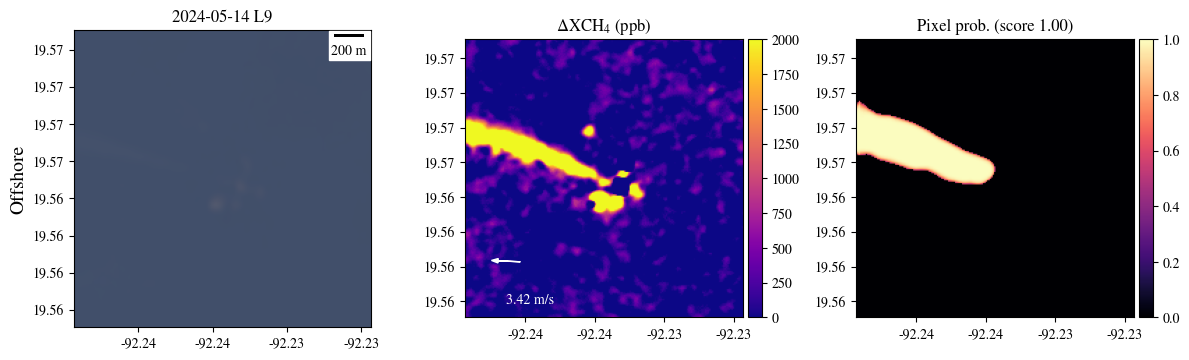

In [10]:
# Check the layout on the highest-scoring example before writing all of them
fig, _ = plot_false_positive(selection.iloc[0])
plt.show(fig)
plt.close(fig)

## 6. Write every example

Files are named after `id_loc_image`, so a figure can be traced straight back to its row of the
prediction CSV. Both PDF (for the manuscript) and PNG (for quick review) are written.

In [11]:
%%time
written = []
for _, row in selection.iterrows():
    fig, _ = plot_false_positive(row)
    stem = pathjoin(FIGURES_DIR, str(row.id_loc_image))
    fig.savefig(f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(f"{stem}.png", bbox_inches="tight", dpi=150)
    plt.close(fig)
    written.append(
        {
            "id_loc_image": str(row.id_loc_image),
            "location_name": row.location_name,
            "country": row.country,
            "satellite": row.satellite,
            "tile_date": row.tile_date,
            "score": row.scenepredcontinuous,
            "offshore": row.offshore,
        }
    )

written = pd.DataFrame(written)
written.to_csv(pathjoin(FIGURES_DIR, "false_positives_selection.csv"), index=False)
print(f"wrote {len(written)} figures to {FIGURES_DIR}")
written

wrote 24 figures to figures/false_positives
CPU times: user 2min 48s, sys: 5.58 s, total: 2min 54s
Wall time: 2min 56s


,id_loc_image,location_name,country,satellite,tile_date,score,offshore
0,0c8c8793-5551-4b7b-8156-25a575bdecf1,MEX_003,Offshore,LC09,2024-05-14 16:34:24.962000+00:00,0.999969,True
1,a94667f9-5f26-485d-a380-4e840a2df65c,Te_N_13,Turkmenistan,LC09,2024-09-15 07:00:57.898000+00:00,0.999969,False
2,c806c1a4-72d6-44db-937d-cc457bc8a677,T_EMIT_1048,Turkmenistan,LC08,2024-02-12 07:01:13.375000+00:00,0.999969,False
3,b44a735b-bca5-4f30-9aee-fbb3c0997747,IRN_f7vpo9skh,Iran (Islamic Republic of),S2B,2024-10-28 07:19:19+00:00,0.999969,False
4,5ea34742-d1a6-4774-a4d7-8fe6a54b6e07,Hakim_2,Libya,S2A,2024-04-05 09:30:31+00:00,0.999968,False
5,cdd5e459-3f88-4472-b35c-745fe17f768d,EGY_mfvxxi0y4,Egypt,LC08,2024-01-27 08:42:24.331000+00:00,0.999968,False
6,6d5b6382-e87c-43f1-98fd-6fd05cb0cdfa,EMIT_CH4_PlumeComplex-50,Turkmenistan,LC09,2024-10-07 06:23:57.286000+00:00,0.999967,False
7,cc97329c-fb12-4ed2-825b-7d9363f5c71e,MEX_005,Offshore,LC09,2024-05-14 16:34:24.962000+00:00,0.999967,True
8,ca1915da-1a25-4af4-acd9-081df4594b09,LBY_off_1,Offshore,LC09,2024-07-10 09:48:34.131000+00:00,0.999966,True
9,802acbc4-669a-41eb-ba48-a479ddaebee7,Samah_2,Libya,LC09,2024-02-07 09:14:01.023000+00:00,0.999964,False


## 7. Building the supplementary figure

Pick 3-5 of the files above that span different artifact causes — changes in surface reflectance
between the reference and target acquisitions, cloud shadow or thin cirrus, smoke, missing pixels
near the swath edges, and low-albedo high-noise backgrounds — and stack them vertically.

Set `IDS_FIGURE` to the chosen `id_loc_image` values and run the cell below; it re-plots those rows
into a single figure with one example per row and writes `figures/false_positives.pdf`.

wrote figures/false_positives.pdf


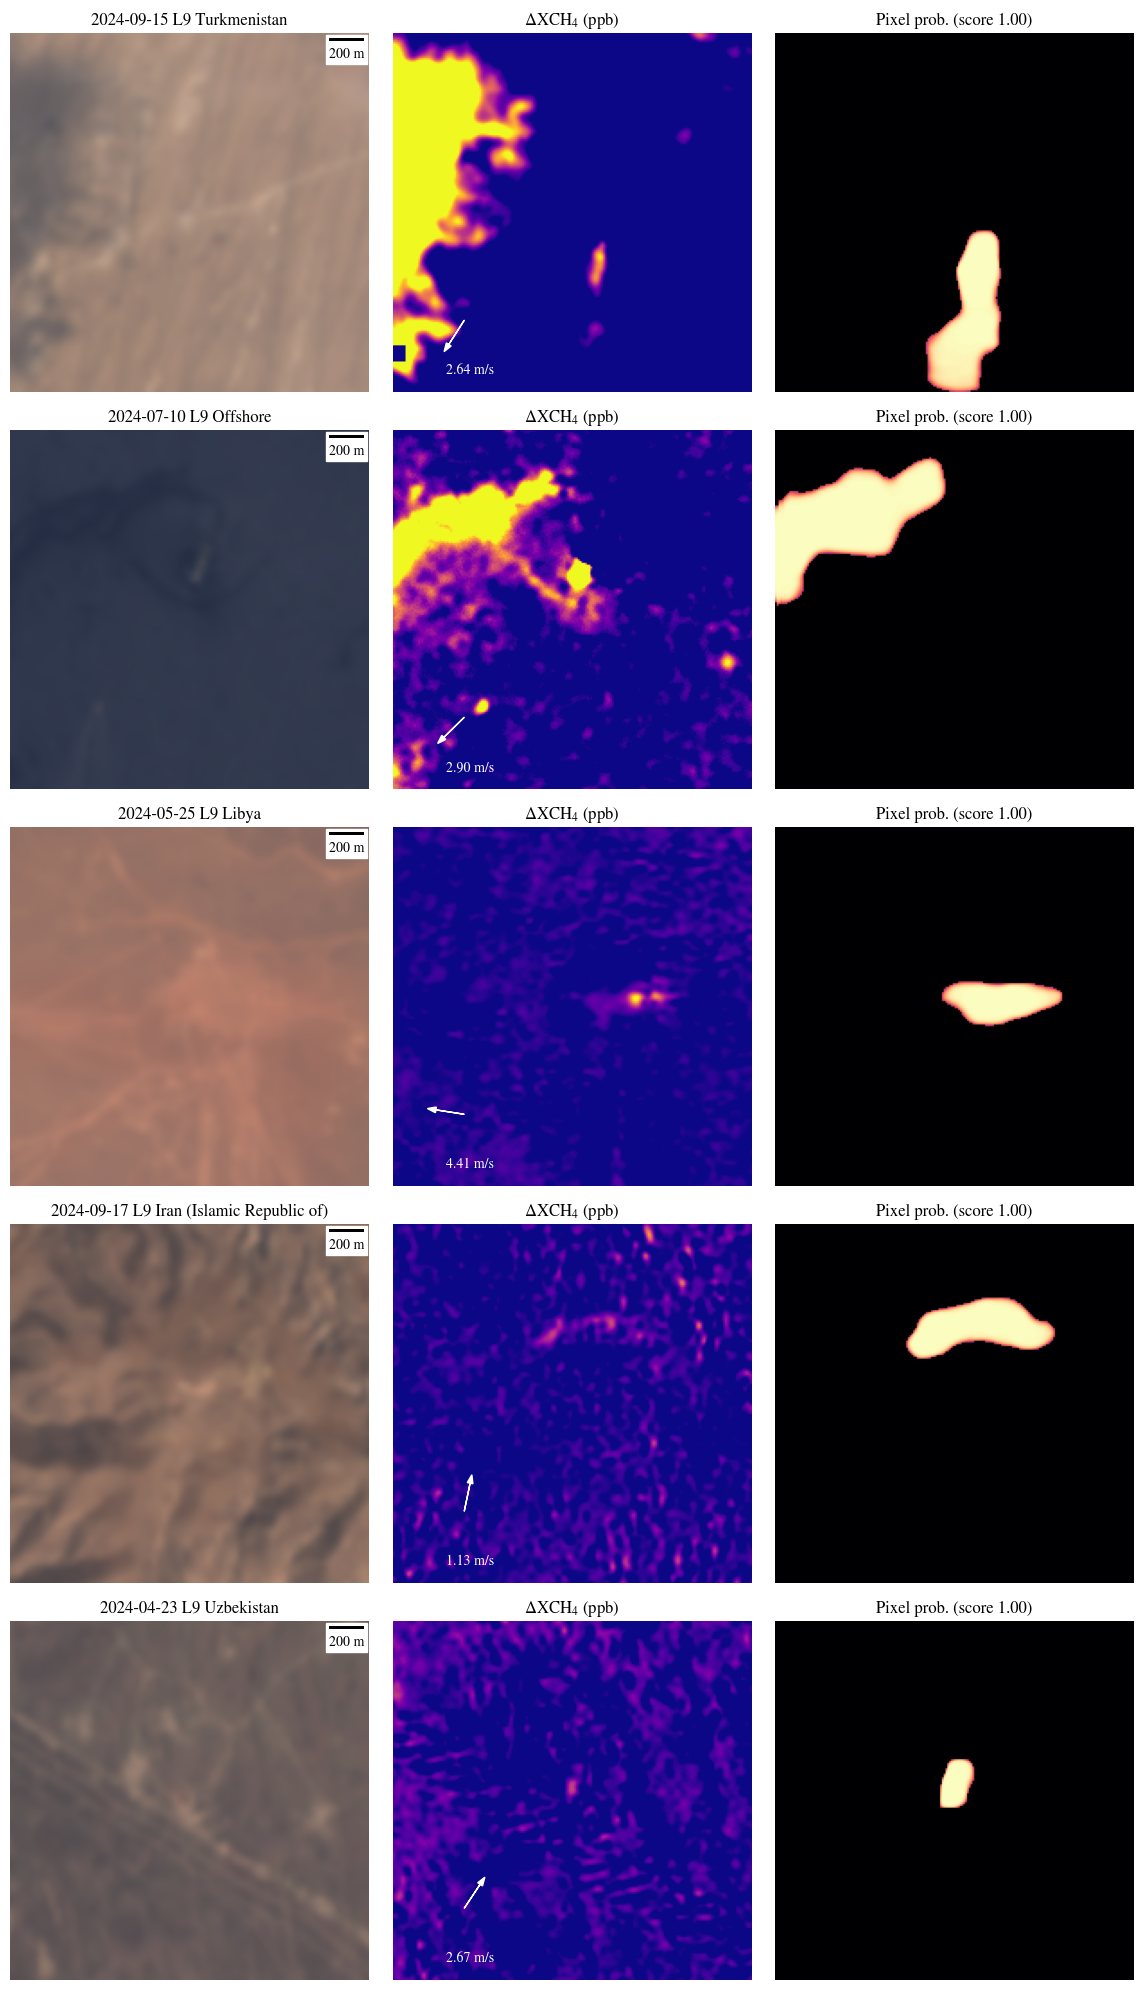

In [25]:
IDS_FIGURE = ["9ee695f5-58a5-4787-b8ad-77f746cddf66", # Turkmenistan shadows
              # "c806c1a4-72d6-44db-937d-cc457bc8a677", # Turkmenistan weak
              "49f78674-eb49-41e0-8733-16fb2bc15be8", # Iran artifact
              "a94667f9-5f26-485d-a380-4e840a2df65c", # Lybia weak
              "68c20f46-9ecc-4cfd-8f05-a30cf1281073", # Uzbekistan weak
              "ca1915da-1a25-4af4-acd9-081df4594b09", # Offshore
              # "8a48ec85-5aaa-4014-a912-194b670e2cf9", # Syria
             ]  # e.g. ["<id_loc_image>", "<id_loc_image>", "<id_loc_image>"]

if IDS_FIGURE:
    ids_str = [str(i) for i in IDS_FIGURE]
    rows = selection[selection.id_loc_image.astype(str).isin(ids_str)]
    missing = set(ids_str) - set(rows.id_loc_image.astype(str))
    assert not missing, f"not in the selection: {missing}"

    fig, axs = plt.subplots(
        len(rows), 3, figsize=(12, 4 * len(rows)), tight_layout=True, squeeze=False
    )
    for i, (_, row) in enumerate(rows.iterrows()):
        plot_false_positive(row, axs=axs[i], add_column_titles=True,
                            add_colorbar_next_to=False)

    for ax in axs.flatten():
        ax.axis("off")

    fig.savefig("figures/false_positives.pdf", bbox_inches="tight")
    print("wrote figures/false_positives.pdf")
else:
    print("set IDS_FIGURE to the ids chosen from the selection above")

## Licence

The `marss2l` package is published under a [GNU Lesser GPL v3 licence](https://www.gnu.org/licenses/lgpl-3.0.en.html)

The *MARS-S2L* database and all pre-trained models are released under a [Creative Commons non-commercial share-alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt).